# Root distribution profile

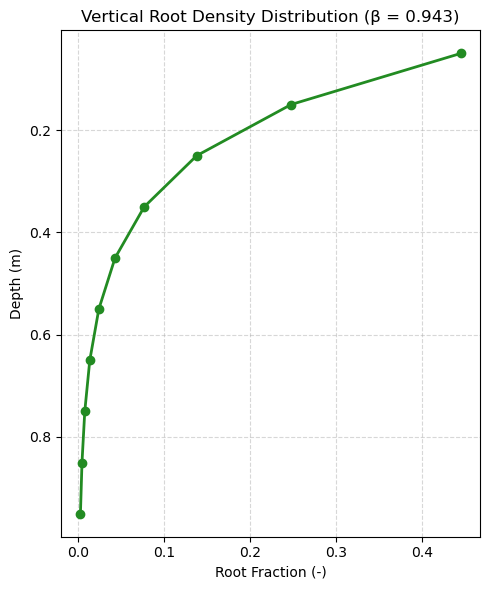

Figure saved to: root_density.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt


figdir = '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/innev/4p1000/Vanderkelen_etal_2025_BG/figures/'


# --- Parameters ---
beta = 0.943  # root distribution parameter for crops
n_levsoi = 10  # number of soil layers
max_depth = 1.0  # maximum soil depth in meters
output_path = "root_density.png"  # path to save the figure

# --- Define soil layer boundaries (z_h in meters) ---
z_h = np.linspace(0, max_depth, n_levsoi + 1)  # layer boundaries

# --- Compute root density per layer using the given formula ---
# r_i = (β^(z_{h,i-1}*100) - β^(z_{h,i}*100))
r = beta ** (z_h[:-1] * 100) - beta ** (z_h[1:] * 100)

# Normalize so that total root fraction = 1
r_norm = r / np.sum(r)

# Compute midpoints of soil layers for plotting
z_mid = (z_h[:-1] + z_h[1:]) / 2

# --- Plot ---
plt.figure(figsize=(5, 6))
plt.plot(r_norm, z_mid, marker='o', color='forestgreen', linewidth=2)
plt.gca().invert_yaxis()  # Depth increases downward
plt.xlabel('Root Fraction (-)')
plt.ylabel('Depth (m)')
plt.title('Vertical Root Density Distribution (β = 0.943)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# --- Save and show figure ---
plt.savefig(figdir+output_path, dpi=300)
plt.show()

print(f"Figure saved to: {output_path}")
